In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score

df=pd.read_csv('iris.csv')

X=df.iloc[:,[1,4]].values
y=df.iloc[:,-1].values

X
y


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [4]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(criterion="entropy",random_state=0)
classifier.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [5]:
y_pred=classifier.predict(X_test)

In [7]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[15,  0,  1],
       [ 0, 13,  0],
       [ 1,  0,  8]])

In [8]:
accuracy=(cm[0][0]+cm[1][1])/cm.sum()

In [9]:
from sklearn import metrics
prediction= metrics.accuracy_score(y_test,y_pred)
print("accuracy",prediction*100,'%')


accuracy 94.73684210526315 %


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       1.00      1.00      1.00        13
           2       0.89      0.89      0.89         9

    accuracy                           0.95        38
   macro avg       0.94      0.94      0.94        38
weighted avg       0.95      0.95      0.95        38



In [11]:
import numpy as np 
new_individual=np.array([[60,50000]])
new_individual_scaled=sc.transform(new_individual)
prediction=classifier.predict(new_individual_scaled)
if prediction[0]==1:
    print("THE PREDICTED SPECIED IS CORRECT")
else:
    print("The predicted specied is wrong")    

The predicted specied is wrong


[Text(0.4, 0.9545454545454546, 'x[1] <= -0.542\nentropy = 1.581\nsamples = 112\nvalue = [34, 37, 41]'),
 Text(0.3, 0.8636363636363636, 'entropy = 0.0\nsamples = 37\nvalue = [0, 37, 0]'),
 Text(0.35, 0.9090909090909092, 'True  '),
 Text(0.5, 0.8636363636363636, 'x[1] <= 0.677\nentropy = 0.994\nsamples = 75\nvalue = [34, 0, 41]'),
 Text(0.45, 0.9090909090909092, '  False'),
 Text(0.2, 0.7727272727272727, 'x[1] <= 0.292\nentropy = 0.494\nsamples = 37\nvalue = [33, 0, 4]'),
 Text(0.1, 0.6818181818181818, 'entropy = 0.0\nsamples = 26\nvalue = [26, 0, 0]'),
 Text(0.3, 0.6818181818181818, 'x[0] <= -0.561\nentropy = 0.946\nsamples = 11\nvalue = [7, 0, 4]'),
 Text(0.2, 0.5909090909090909, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4, 0.5909090909090909, 'x[0] <= 1.341\nentropy = 0.881\nsamples = 10\nvalue = [7, 0, 3]'),
 Text(0.3, 0.5, 'x[1] <= 0.421\nentropy = 0.764\nsamples = 9\nvalue = [7, 0, 2]'),
 Text(0.2, 0.4090909090909091, 'x[0] <= 0.073\nentropy = 0.918\nsamples = 6\nva

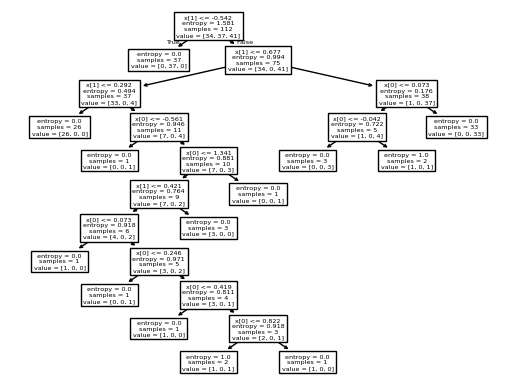

In [12]:
from sklearn import tree
tree.plot_tree(classifier)